# Test 1

In [21]:
import sys
sys.path.append("..")
import numpy as np
import torch
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from config import Config
from actor import Actor
from critic import Critic
from tqdm import tqdm, trange
from utils import device

rng = np.random.default_rng(0)

env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

config = Config(
    state_dim = state_dim,
    action_dim = action_dim,
    action_tanh = False,
    num_encoders = 2,
    tree_depth = 2,
    critic_num_hidden_layers = 6,
    actor_num_hidden_layers = 4,
    embed_dim = 32,
    discount_rate = 0.97,
    learning_rate = 1e-3,
    critic_polyak_factor = 0.05,
    actor_polyak_factor = 0.001,
    batch_size = 64,
    num_episodes = 5000,
    replay_buffer_size = 10000,
    add_probability = 1.0,
    critic_update_interval = 10,
    actor_update_interval = 10,
    noise_std = 0.01,
    noise_std_min = 0.0001,
    noise_std_decay = 0.99995,
)

actor = Actor(config, rng).to(device)
critic = Critic(config, rng).to(device)
episode_rewards = []
noise_std = config.noise_std
reward_ema = 0.0

In [25]:
from collections import deque

recent = deque()
train_updates = 0
print_interval = 10

episode_rewards = []

for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        with torch.no_grad():
            _, action = actor.forward(state, noise_std = noise_std)

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

        if np.random.rand() < config.add_probability:
            recent.append((state, action, reward_t, done_t, next_state_t))

        state = next_state_t
        episode_reward += float(reward)

        if len(recent) >= config.batch_size:
            recent_batch = list(recent)[-config.batch_size:]

            batch_state = torch.cat([x[0] for x in recent_batch], dim = 0)
            batch_action = torch.cat([x[1] for x in recent_batch], dim = 0)
            batch_reward = torch.cat([x[2] for x in recent_batch], dim = 0)
            batch_done = torch.cat([x[3] for x in recent_batch], dim = 0)
            batch_next_state = torch.cat([x[4] for x in recent_batch], dim = 0)

            with torch.no_grad():
                batch_actor_embeds, _ = actor.forward(batch_state, noise_std = noise_std)

            critic_loss, target_q_value, module_idx = critic.train(
                actor = actor,
                state = batch_state,
                actor_embeds = batch_actor_embeds,
                action = batch_action,
                reward = batch_reward,
                done = batch_done,
                next_state = batch_next_state,
            )
            actor_loss = actor.train(critic = critic, state = batch_state)

            train_updates += 1
            if train_updates % print_interval == 0:
                print(train_updates, critic_loss, actor_loss, target_q_value, noise_std)

            recent.clear()
            noise_std = max(config.noise_std_min, noise_std * config.noise_std_decay)

    episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 0/5000 [00:00<?, ?it/s]

TypeError: FNN.forward() got an unexpected keyword argument 'noise_std'

[-20.011829980623222,
 -18.617533753719528,
 -19.71527580239134,
 -17.93099697419594,
 -21.069893238766085,
 -17.918031624807384,
 -18.881144389989814,
 -20.765817925294932,
 -18.439601969791664,
 -20.361588918957892,
 -20.037929475312826,
 -19.807849830873607,
 -18.008001103307002,
 -19.822042715325118,
 -19.73547105696743,
 -19.316614434345112,
 -18.814041990906844,
 -19.02744760856125,
 -16.672399777086202,
 -18.62644500076441,
 -18.5053850953239,
 -19.48484408914681,
 -19.3098689617307,
 -18.571559108555885,
 -19.932056191228163,
 -19.118614552298514,
 -18.918923477380496,
 -19.809782379583776,
 -19.745206111617925,
 -19.12615013193248,
 -18.848069227598582,
 -20.276582270913263,
 -19.367313909666425,
 -20.19064611864004,
 -19.23013916071515,
 -19.045513965145297,
 -19.68596822982311,
 -18.698398650192182,
 -20.3590162772945,
 -18.84490510808407,
 -20.248535766724505]

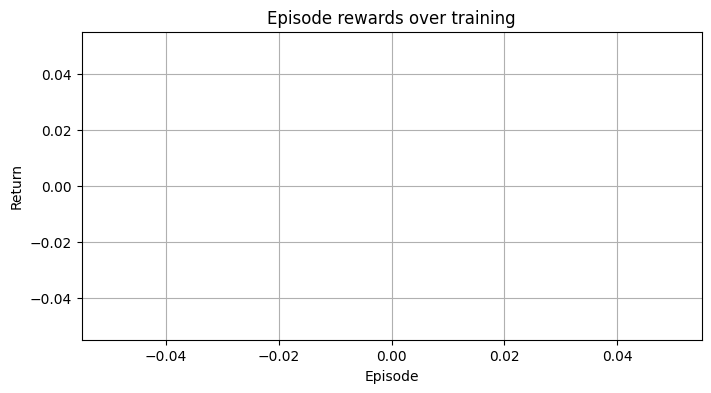

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Episode rewards over training")
plt.grid(True)
plt.show()

# Test 2

In [30]:
import sys
sys.path.append("..")
import numpy as np
import torch
from torch import nn, optim
from torch.nn.functional import mse_loss
from fnn import FNN
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from config import Config
from actor import Actor
from critic import Critic
from tqdm import tqdm, trange
from utils import device, polyak_update

rng = np.random.default_rng(0)

env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

config = Config(
    state_dim = state_dim + action_dim,
    action_dim = 1,
    action_tanh = False,
    num_encoders = 2,
    tree_depth = 2,
    critic_num_hidden_layers = 6,
    actor_num_hidden_layers = 4,
    embed_dim = 32,
    discount_rate = 0.97,
    learning_rate = 1e-3,
    critic_polyak_factor = 0.05,
    actor_polyak_factor = 0.05,
    batch_size = 64,
    num_episodes = 5000,
    replay_buffer_size = 10000,
    add_probability = 1.0,
    critic_update_interval = 10,
    actor_update_interval = 10,
    noise_std = 0.1,
    noise_std_min = 0.0001,
    noise_std_decay = 0.99995,
)

critic = Actor(config, rng).to(device)
actor = FNN(
    input_size = state_dim,
    output_size = action_dim,
    hidden_size = 128,
    num_hidden_layers = 8,
    output_activation = nn.Tanh(),
).to(device)
episode_rewards = []
noise_std = config.noise_std
reward_ema = 0.0

In [27]:
from collections import deque

from fnn import FNN
from torch.nn.utils import clip_grad_norm_

recent = deque()
train_updates = 0
print_interval = 10
actor_optimizer = optim.Adam(actor.parameters(), lr = 1e-3)
critic_optimizer = optim.Adam(critic.parameters(), lr = 1e-3)

actor_target = FNN(
    input_size = state_dim,
    hidden_size = 128,
    num_hidden_layers = 8,
    output_size = action_dim,
).to(device)
actor_target.load_state_dict(actor.state_dict())
for param in actor_target.parameters():
    param.requires_grad_(False)

for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        with torch.no_grad():
            action = actor_target.forward(state)
            action += torch.randn_like(action) * noise_std

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

        if rng.random() < config.add_probability:
            recent.append((state, action, reward_t, done_t, next_state_t))

        state = next_state_t
        episode_reward += float(reward)

        if len(recent) >= config.batch_size:
            indices = rng.integers(0, len(recent), size = config.batch_size)            
            batch = [recent[i] for i in indices]

            batch_state = torch.cat([x[0] for x in batch], dim = 0)
            batch_action = torch.cat([x[1] for x in batch], dim = 0)
            batch_reward = torch.cat([x[2] for x in batch], dim = 0)
            batch_done = torch.cat([x[3] for x in batch], dim = 0)
            batch_next_state = torch.cat([x[4] for x in batch], dim = 0)

            module_idx = int(rng.integers(0, len(critic._online_models)))
            state_action = torch.cat([batch_state, batch_action], dim = 1)
            _, q_value = critic.forward(state_action, module_idx = module_idx)

            with torch.no_grad():
                next_action = actor_target.forward(batch_next_state)
            next_state_action = torch.cat([batch_next_state, next_action], dim = 1)
            _, next_q_value = critic.forward(next_state_action)
            target_q_value = batch_reward + (1 - batch_done) * config.discount_rate * next_q_value

            assert target_q_value.shape == q_value.shape and not target_q_value.requires_grad

            critic_loss = mse_loss(q_value, target_q_value)
            critic_loss.backward()
            clip_grad_norm_(critic.parameters(), max_norm = 1.0)
            critic_optimizer.step()
            critic_optimizer.zero_grad(set_to_none = True)
            polyak_update(critic._target_models[module_idx], critic._online_models[module_idx], config.critic_polyak_factor)

            action = actor.forward(batch_state)
            state_action = torch.cat([batch_state, action], dim = 1)
            _, q_value = critic.forward(state_action)
            actor_loss = -q_value.mean()
            actor_loss.backward()
            clip_grad_norm_(actor.parameters(), max_norm = 1.0)
            actor_optimizer.step()
            actor_optimizer.zero_grad(set_to_none = True)
            polyak_update(actor_target, actor, config.actor_polyak_factor)

            train_updates += 1
            if train_updates % print_interval == 0:
                print(train_updates, critic_loss.item(), actor_loss.item(), target_q_value.mean().item(), noise_std)

            noise_std = max(config.noise_std_min, noise_std * config.noise_std_decay)

    episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 0/5000 [00:00<?, ?it/s]


AttributeError: 'FNN' object has no attribute '_online_models'

In [28]:
# --- Record and display a video rollout in notebook ---

import os
from glob import glob

import gymnasium as gym

from IPython.display import Video
from gymnasium.wrappers import RecordVideo, TimeLimit


video_dir = "./videos/mod_test_fnn_actor_modular_critic"
os.makedirs(video_dir, exist_ok = True)

video_env = gym.make("HalfCheetah-v5", render_mode = "rgb_array")
video_env = TimeLimit(video_env, max_episode_steps = 500)
video_env = RecordVideo(
    video_env,
    video_folder = video_dir,
    episode_trigger = lambda episode_id: True,
    name_prefix = "rollout",
)

state_np, _ = video_env.reset(seed = 0)
terminated = False
truncated = False

while not terminated and not truncated:
    state_t = torch.tensor(state_np, dtype = torch.float32, device = device).unsqueeze(0)
    with torch.no_grad():
        action_t = actor_target.forward(state_t)
    state_np, _, terminated, truncated, _ = video_env.step(action_t[0].cpu().numpy())

video_env.close()

video_files = sorted(glob(os.path.join(video_dir, "rollout-episode-*.mp4")))
if len(video_files) == 0:
    raise FileNotFoundError(f"No mp4 found in {os.path.abspath(video_dir)}")

latest_video = video_files[-1]
print("Saved video to:", os.path.abspath(latest_video))
Video(latest_video, embed = True, html_attributes = "controls autoplay loop")

c:\Users\abhay\anaconda3\envs\ursa25\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\abhay\Desktop\abhay\python-proj\mutualistic-agents\notebooks\videos\mod_test_fnn_actor_modular_critic folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video to: c:\Users\abhay\Desktop\abhay\python-proj\mutualistic-agents\notebooks\videos\mod_test_fnn_actor_modular_critic\rollout-episode-0.mp4


# Test 3

In [42]:
actor = FNN(
    input_size = state_dim,
    output_size = action_dim,
    hidden_size = 128,
    num_hidden_layers = 8,
    output_activation = nn.Tanh(),
).to(device)
critic1 = FNN(
    input_size = state_dim + action_dim,
    output_size = 1,
    hidden_size = 128,
    num_hidden_layers = 8,
).to(device)
critic2 = FNN(
    input_size = state_dim + action_dim,
    output_size = 1,
    hidden_size = 128,
    num_hidden_layers = 8,
).to(device)


from collections import deque

from fnn import FNN
from torch.nn.utils import clip_grad_norm_

recent = deque(maxlen = config.replay_buffer_size)
train_updates = 0
print_interval = 100
actor_optimizer = optim.Adam(actor.parameters(), lr = 1e-3)
critic_optimizer = optim.Adam(list(critic1.parameters()) + list(critic2.parameters()), lr = 1e-3)

actor_target = FNN(
    input_size = state_dim,
    hidden_size = 128,
    num_hidden_layers = 8,
    output_size = action_dim,
).to(device)
actor_target.load_state_dict(actor.state_dict())
for param in actor_target.parameters():
    param.requires_grad_(False)
critic1_target = FNN(
    input_size = state_dim + action_dim,
    output_size = 1,
    hidden_size = 128,
    num_hidden_layers = 8,
).to(device)
critic1_target.load_state_dict(critic1.state_dict())
for param in critic1_target.parameters():
    param.requires_grad_(False)
critic2_target = FNN(
    input_size = state_dim + action_dim,
    output_size = 1,
    hidden_size = 128,
    num_hidden_layers = 8,
).to(device)
critic2_target.load_state_dict(critic2.state_dict())
for param in critic2_target.parameters():
    param.requires_grad_(False)

i = 0
for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        with torch.no_grad():
            action = actor.forward(state)
        action += torch.randn_like(action) * noise_std
        action = action.clamp(-1.0, 1.0)

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

        if rng.random() < config.add_probability:
            recent.append((state, action, reward_t, done_t, next_state_t))

        state = next_state_t
        episode_reward += float(reward)

        i += 1
        if len(recent) >= config.batch_size and i % 5 == 0:
            indices = rng.integers(0, len(recent), size = config.batch_size)            
            batch = [recent[i] for i in indices]

            batch_state = torch.cat([x[0] for x in batch], dim = 0)
            batch_action = torch.cat([x[1] for x in batch], dim = 0)
            batch_reward = torch.cat([x[2] for x in batch], dim = 0)
            batch_done = torch.cat([x[3] for x in batch], dim = 0)
            batch_next_state = torch.cat([x[4] for x in batch], dim = 0)

            state_action = torch.cat([batch_state, batch_action], dim = 1)
            q_value1 = critic1.forward(state_action)
            q_value2 = critic2.forward(state_action)
            with torch.no_grad():
                next_action = actor_target.forward(batch_next_state)
                next_action = next_action + torch.randn_like(next_action) * min(noise_std, 0.2)
                next_action = next_action.clamp(-1.0, 1.0)
                next_state_action = torch.cat([batch_next_state, next_action], dim = 1)
                next_q_value1 = critic1_target.forward(next_state_action)
                next_q_value2 = critic2_target.forward(next_state_action)
                next_q_value = torch.min(next_q_value1, next_q_value2)
                target_q_value = batch_reward + (1 - batch_done) * config.discount_rate * next_q_value

            assert target_q_value.shape == q_value1.shape and not target_q_value.requires_grad

            critic_loss = mse_loss(q_value1, target_q_value) + mse_loss(q_value2, target_q_value)
            critic_loss.backward()
            clip_grad_norm_(critic1.parameters(), max_norm = 1.0)
            clip_grad_norm_(critic2.parameters(), max_norm = 1.0)
            critic_optimizer.step()
            critic_optimizer.zero_grad(set_to_none = True)
            polyak_update(critic1_target, critic1, config.critic_polyak_factor)
            polyak_update(critic2_target, critic2, config.critic_polyak_factor)

            actor_loss = torch.tensor(0.0, device = device)
            action = actor.forward(batch_state)
            state_action = torch.cat([batch_state, action], dim = 1)
            q_value1 = critic1.forward(state_action)
            q_value2 = critic2.forward(state_action)
            q_value = torch.min(q_value1, q_value2)
            actor_loss = -q_value.mean()
            actor_loss.backward()
            clip_grad_norm_(actor.parameters(), max_norm = 1.0)
            actor_optimizer.step()
            actor_optimizer.zero_grad(set_to_none = True)
            polyak_update(actor_target, actor, config.actor_polyak_factor)

            train_updates += 1
            if train_updates % print_interval == 0:
                print(f"{train_updates}, cl: {critic_loss.item():.6f}, al: {actor_loss.item():.6f}, tq: {target_q_value.mean().item():.6f}, ns: {noise_std:.6f}, re: {episode_reward:.6f}")

            noise_std = max(config.noise_std_min, noise_std * config.noise_std_decay)

    episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 1/5000 [00:03<5:03:49,  3.65s/it]

100, cl: 0.472414, al: -3.648846, tq: 2.511046, ns: 0.031447, re: -29.185639


  0%|          | 2/5000 [00:07<5:19:36,  3.84s/it]

200, cl: 0.457778, al: -8.029568, tq: 6.868732, ns: 0.031290, re: -34.105201


  0%|          | 3/5000 [00:11<5:23:41,  3.89s/it]

...

499800, cl: 0.282953, al: 7.536637, tq: -7.905363, ns: 0.000100, re: -38.407474


100%|█████████▉| 4999/5000 [18:06:10<00:04,  4.06s/it]

499900, cl: 0.288018, al: 7.658276, tq: -7.930702, ns: 0.000100, re: -37.382416


100%|██████████| 5000/5000 [18:06:14<00:00, 13.03s/it]


[-195.22170855571596,
 -258.72831870924756,
 -261.09675262066463,
 -283.05310164920377,
 -275.7781103758109,
 -238.1809109514954,
 -289.70665127191785,
 -272.59730419674236,
 -257.52468119617197,
 -285.6376763386974,
 -287.50441098968656,
 -260.4436737449304,
 -268.30346005181457,
 -284.29982321055564,
 -295.19753708414873,
 -186.71464888938326,
 -245.141688349054,
 -255.11279773869933,
 -275.021025884382,
 -280.0492083786666,
 -211.24719075374696,
 -270.4173356668293,
 -279.5954516648216,
 -270.12486027356925,
 -270.8749499821669,
 -264.25594696327,
 -291.0140265722455,
 -289.47043145827433,
 -259.1740611947299,
 -293.2785276061655,
 -258.59077566207384,
 -269.40931597622154,
 -275.96946414018794,
 -276.1566192238266,
 -297.58849195114215,
 -277.0998943643907,
 -260.70139250777277,
 -247.20582346850284,
 -239.8647985875261,
 -247.84656132799333,
 -247.7599464098745,
 -260.5346484667695,
 -295.0516359070351,
 -267.49265495149535,
 -282.63849603239987,
 -262.1419755825607,
 -295.9380604